In [1]:
import copy, math, random, importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import parameters
import data_handling
import particle_filter as _pf_mod
importlib.reload(_pf_mod)
from particle_filter import (
    Map, State, ParticleFilter, ParticleSet, find_initial_pose
)

In [2]:
map_obj = Map(parameters.wall_corner_list)

filename = './data/robot_data_73_-20_13_03_26_19_01_49.pkl'
pf_data = data_handling.get_file_data_for_pf(filename)

# Good initial guess from grid search
good_guess = find_initial_pose(map_obj, pf_data[0][2])
print(f"Good guess: ({good_guess.x:.3f}, {good_guess.y:.3f}, {math.degrees(good_guess.theta):.1f}°)")

# Bad initial guess: offset by ~1.5 m and 90°
bad_guess = State(good_guess.x + 1.5, good_guess.y + 1.5,
                  good_guess.theta + math.pi / 2)
print(f"Bad guess:  ({bad_guess.x:.3f}, {bad_guess.y:.3f}, {math.degrees(bad_guess.theta):.1f}°)")

Pre-localization: (0.620, 0.058, 2.0°)  log_w=-1.48
Good guess: (0.620, 0.058, 2.0°)
Bad guess:  (2.120, 1.558, 92.0°)


In [3]:
def collect_max_weights(map_obj, pf_data, initial_state, known_start, max_steps=None):
    """Run PF once with reinit disabled; return list of PRE-RESAMPLE max particle weights per step."""
    old_cr = parameters.reinit_cycles_required
    parameters.reinit_cycles_required = 999999  # effectively disable reinit

    pf = ParticleFilter(
        parameters.num_particles,
        map_obj,
        initial_state=initial_state,
        state_stdev=State(0.3, 0.3, 0.3),
        known_start_state=known_start,
        encoder_counts_0=pf_data[0][2].encoder_counts,
    )

    max_weights = []
    n = len(pf_data) if max_steps is None else min(max_steps + 1, len(pf_data))
    for t in range(1, n):
        row = pf_data[t]
        delta_t = pf_data[t][0] - pf_data[t - 1][0]
        u_t = np.array([row[2].encoder_counts, row[2].steering])
        z_t = row[2]
        pf.update(u_t, z_t, delta_t)
        # Read the max weight captured BEFORE resample reset weights to 1
        max_weights.append(pf.particle_set._last_pre_resample_max_w)

    parameters.reinit_cycles_required = old_cr
    return max_weights


def simulate_reinit(max_weights, weight_thresh, cycles_req):
    """Simulate streak logic on recorded max-weights. Returns reinit count and first reinit step (or None)."""
    streak = 0
    reinit_count = 0
    first_reinit = None
    for i, mw in enumerate(max_weights):
        if mw < weight_thresh:
            streak += 1
        else:
            streak = 0
        if streak >= cycles_req:
            reinit_count += 1
            if first_reinit is None:
                first_reinit = i
            streak = 0  # reset after reinit
    return reinit_count, first_reinit

In [ ]:
weight_thresholds = [1e-15, 1e-12, 1e-10, 1e-9, 1e-7, 1e-5, 1e-3]
cycles_required   = [1, 2, 3, 4, 5, 7, 10]

MAX_STEPS = 40  # steps for the grid sweep 

In [5]:
scenarios = {
    'Good guess (known)':   (good_guess, True),
    'Bad guess (known)':    (bad_guess,  True),
    'Unknown start':        (good_guess, False),  # known_start=False → uniform grid
}

# One PF run per scenario (reinit disabled)
mw_cache = {}
for name, (init_state, known) in scenarios.items():
    print(f"Running PF: {name} …")
    mw_cache[name] = collect_max_weights(map_obj, pf_data, init_state, known, MAX_STEPS)
    print(f"  {len(mw_cache[name])} steps recorded")

# Offline sweep
results = {}
for name in scenarios:
    grid = np.zeros((len(weight_thresholds), len(cycles_required)), dtype=int)
    for i, wt in enumerate(weight_thresholds):
        for j, cr in enumerate(cycles_required):
            grid[i, j], _ = simulate_reinit(mw_cache[name], wt, cr)
    results[name] = grid
print("Done.")

Running PF: Good guess (known) …
Known
  40 steps recorded
Running PF: Bad guess (known) …
Known
  40 steps recorded
Running PF: Unknown start …
  40 steps recorded
Done.


/var/folders/mh/4_lxl3vj0fvfk7d2dk2ss6nc0000gn/T/ipykernel_40231/467652350.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


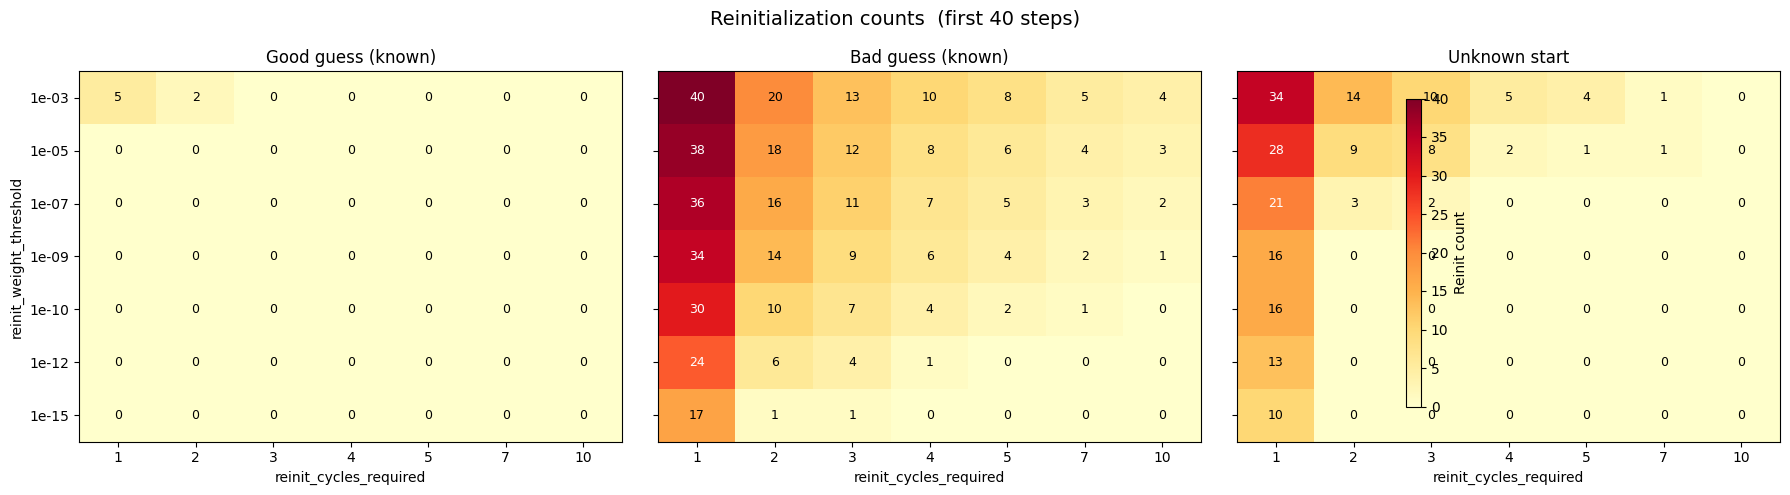

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

vmax = max(g.max() for g in results.values()) or 1
cmap = plt.cm.YlOrRd

for ax, (name, grid) in zip(axes, results.items()):
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=vmax, aspect='auto',
                   origin='lower')
    ax.set_xticks(range(len(cycles_required)))
    ax.set_xticklabels(cycles_required)
    ax.set_yticks(range(len(weight_thresholds)))
    ax.set_yticklabels([f'{v:.0e}' for v in weight_thresholds])
    ax.set_xlabel('reinit_cycles_required')
    if ax is axes[0]:
        ax.set_ylabel('reinit_weight_threshold')
    ax.set_title(name)
    # annotate cells
    for ii in range(grid.shape[0]):
        for jj in range(grid.shape[1]):
            ax.text(jj, ii, str(grid[ii, jj]), ha='center', va='center',
                    color='white' if grid[ii, jj] > vmax / 2 else 'black',
                    fontsize=9)

fig.colorbar(im, ax=axes, label='Reinit count', shrink=0.8)
fig.suptitle(f'Reinitialization counts  (first {MAX_STEPS} steps)', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
good = results['Good guess (known)']
bad  = results['Bad guess (known)']
unk  = results['Unknown start']

feasible = (good == 0) & ((bad > 0) | (unk > 0))

print("Feasible (threshold, cycles) combinations:")
print(f"{'threshold':>12s}  {'cycles':>6s}  {'bad reinits':>11s}  {'unk reinits':>11s}")
for i in range(len(weight_thresholds)):
    for j in range(len(cycles_required)):
        if feasible[i, j]:
            print(f"{weight_thresholds[i]:>12.0e}  {cycles_required[j]:>6d}"
                  f"  {bad[i, j]:>11d}  {unk[i, j]:>11d}")

if not feasible.any():
    print("No feasible combination found — try widening the grid.")

Feasible (threshold, cycles) combinations:
   threshold  cycles  bad reinits  unk reinits
       1e-15       1           17           10
       1e-15       2            1            0
       1e-15       3            1            0
       1e-12       1           24           13
       1e-12       2            6            0
       1e-12       3            4            0
       1e-12       4            1            0
       1e-10       1           30           16
       1e-10       2           10            0
       1e-10       3            7            0
       1e-10       4            4            0
       1e-10       5            2            0
       1e-10       7            1            0
       1e-09       1           34           16
       1e-09       2           14            0
       1e-09       3            9            0
       1e-09       4            6            0
       1e-09       5            4            0
       1e-09       7            2            0
       1e-09     